# EX3 Logistic Regression: Breast Cancer

In [1]:
#%pip install scikit-learn

In [2]:
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.optim as opt
import numpy as np
from matplotlib import pyplot as plt

## data preprocessing

In [3]:
dataset = load_breast_cancer()
X,y = dataset.data,dataset.target

In [4]:
X[0]

array([1.799e+01, 1.038e+01, 1.228e+02, 1.001e+03, 1.184e-01, 2.776e-01,
       3.001e-01, 1.471e-01, 2.419e-01, 7.871e-02, 1.095e+00, 9.053e-01,
       8.589e+00, 1.534e+02, 6.399e-03, 4.904e-02, 5.373e-02, 1.587e-02,
       3.003e-02, 6.193e-03, 2.538e+01, 1.733e+01, 1.846e+02, 2.019e+03,
       1.622e-01, 6.656e-01, 7.119e-01, 2.654e-01, 4.601e-01, 1.189e-01])

In [5]:
y[0]

0

train test split

In [6]:
print(f'X shape {X.shape} y shape {y.shape}')
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.33)

X shape (569, 30) y shape (569,)


normalize data

In [7]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

convert to torch tensors

In [8]:
y_train = y_train.reshape(-1,1)
y_test = y_test.reshape(-1,1)
train_inputs = torch.from_numpy(X_train.astype(np.float32))
test_inputs = torch.from_numpy(X_test.astype(np.float32))
train_targets = torch.from_numpy(y_train.astype(np.float32))
test_targets = torch.from_numpy(y_test.astype(np.float32))

## building the model

In [9]:
D = X_test.shape[1]

model = nn.Sequential(
    nn.Linear(D,1),
    nn.Sigmoid()
)
optimizer = opt.Adam(model.parameters(),lr=0.01)
criterion = nn.BCELoss()

## training the model

In [10]:
EPOCHS = 700
train_losses = []
test_losses= []
train_accuracies = []
test_accuracies = []

In [11]:
for epoch in range(EPOCHS):
    optimizer.zero_grad()

    predictions = model(train_inputs)
    loss = criterion(predictions,train_targets)
    train_losses.append(loss.item())
    loss.backward()
    optimizer.step()

    #train acc
    train_preds = np.round(predictions.detach().numpy())
    train_acc = np.mean(train_preds == train_targets.detach().numpy())
    train_accuracies.append(train_acc.item())

    #test loss
    outs_test = model(test_inputs)
    test_loss = criterion(outs_test,test_targets)
    test_losses.append(test_loss.item())

    #test acc
    test_preds = np.round(outs_test.detach().numpy())
    test_acc = np.mean(test_preds == test_targets.detach().numpy())
    test_accuracies.append(test_acc.item())
    #test loss every 50 epochs
    if (epoch + 1) % 50 == 0:
       
        print(f'{epoch +1}/{EPOCHS} train loss: {loss.item():.4f} test loss: {test_loss.item():.4f} train acc: {train_acc.item():.4f} val acc: {test_acc.item():.4f}')
 

50/700 train loss: 0.1138 test loss: 0.1583 train acc: 0.9790 val acc: 0.9574
100/700 train loss: 0.0801 test loss: 0.1285 train acc: 0.9843 val acc: 0.9681
150/700 train loss: 0.0663 test loss: 0.1170 train acc: 0.9869 val acc: 0.9734
200/700 train loss: 0.0581 test loss: 0.1106 train acc: 0.9869 val acc: 0.9840
250/700 train loss: 0.0525 test loss: 0.1067 train acc: 0.9869 val acc: 0.9840
300/700 train loss: 0.0484 test loss: 0.1042 train acc: 0.9869 val acc: 0.9840
350/700 train loss: 0.0452 test loss: 0.1026 train acc: 0.9869 val acc: 0.9787
400/700 train loss: 0.0427 test loss: 0.1016 train acc: 0.9869 val acc: 0.9734
450/700 train loss: 0.0406 test loss: 0.1012 train acc: 0.9869 val acc: 0.9734
500/700 train loss: 0.0389 test loss: 0.1011 train acc: 0.9895 val acc: 0.9734
550/700 train loss: 0.0374 test loss: 0.1014 train acc: 0.9895 val acc: 0.9681
600/700 train loss: 0.0361 test loss: 0.1020 train acc: 0.9921 val acc: 0.9681
650/700 train loss: 0.0350 test loss: 0.1029 train ac

## plot the loss and accuracy

In [12]:

epochs = [i for i in range(len(train_losses))]

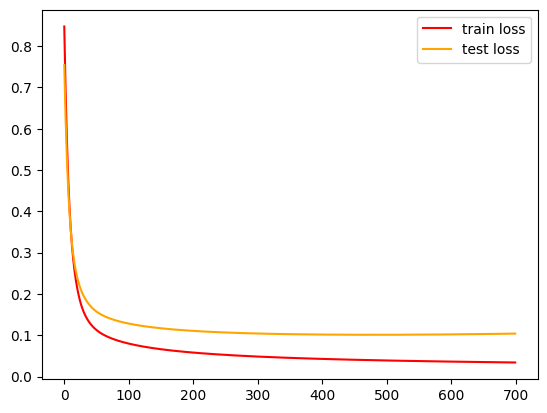

In [13]:
plt.plot(epochs,train_losses,label='train loss',color='red')
plt.plot(epochs,test_losses,label='test loss',color='orange')
plt.legend()
plt.xlabel = 'epochs'
plt.show()

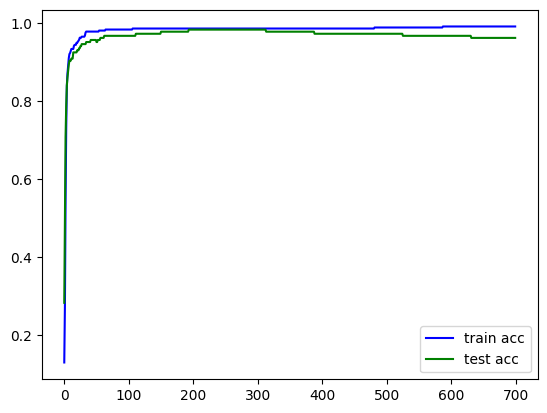

In [14]:
plt.plot(epochs,train_accuracies,label='train acc',color='blue')
plt.plot(epochs,test_accuracies,label='test acc',color='green')
plt.legend()
plt.xlabel = 'epochs'
plt.show()

## predict

In [15]:
with torch.no_grad():
    preds_train = model(train_inputs)
    preds_train = np.round(preds_train.numpy()) #since it's probability it's not exactly 1 and 0 yet os we round it
    train_acc = np.mean(train_targets.numpy() == preds_train)
# train_targets.numpy() == preds_train
# Creates a vector of true/false but numpy treat True as 1 and false as 0
# So we can just count the number of 1s or JUST ADD THEM to get
# the number of correct predictions! But mean also divide it with th TOTAL NUMBER OF PREDICTIONS thus we got accuracy

    pred_test = model(test_inputs)
    pred_test = np.round(pred_test.numpy())
    test_acc = np.mean(test_targets.numpy() == pred_test)
    print(f'train acc {train_acc} test acc {test_acc}')
    

train acc 0.9921259842519685 test acc 0.9627659574468085


# Saving and Loading a Model

In [16]:
model.state_dict()

OrderedDict([('0.weight',
              tensor([[-0.7503, -0.8938, -0.5068, -0.5275, -0.6728, -0.2015, -0.8293, -0.7819,
                       -0.0289,  1.1472, -1.0641,  0.9085, -0.9939, -0.9732, -0.4219,  1.2755,
                       -0.4379, -0.4358,  0.2198,  1.2996, -0.7818, -1.4129, -0.8214, -0.7605,
                       -0.8702, -0.2251, -0.6551, -0.6088, -0.9047, -0.6775]])),
             ('0.bias', tensor([0.4695]))])

In [17]:
torch.save(model.state_dict(),'../MODELS/cancer_classification.pt')